In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams['font.size'] = 14

color_list = [
    "#a6cee3",  # 0  light blue
    "#1f78b4",  # 1  dark blue
    "#b2df8a",  # 2  light green
    "#33a02c",  # 3  dark green
    "#fb9a99",  # 4  light red
    "#e31a1c",  # 5  dark red
    "#fdbf6f",  # 6  light orange
    "#ff7f00",  # 7  dark orange
    "#cab2d6",  # 8  light purple
    "#6a3d9a",  # 9  dark purple
    "#ffff99",  # 10 yellow
    "#b15928",  # 11 brown
]

COLOR_LOW  = color_list[0]   # light blue  — low parameter value
COLOR_HIGH = color_list[1]   # dark blue   — high parameter value
BAR_HEIGHT = 0.45
BASELINE   = 0.0

In [3]:
base_path = r'C:\Users\sss0031\Documents\GitHub\watertap'

sensitivity_data = {}
for i in range(1, 15):
    sensitivity_data[i] = pd.read_csv(f'{base_path}\\sensitivity_lcow_{i}.csv')

In [4]:
# ---------------------------------------------------------------------------
# Parameter groups — listed top to bottom in the final plot.
# Within each group, rows are sorted by swing size (largest first = top).
# ---------------------------------------------------------------------------
groups = [
    {
        "name": "Chemical\naddition",
        "params": [
            (14, "Feed pH of 1st pass RO"),
            ( 1, "HCl cost"),
            ( 2, "NaOH cost"),
            (12, "Mixer capital cost"),
        ],
    },
    {
        "name": "Reverse\nosmosis",
        "params": [
            ( 9, "Membrane cost"),
            (10, "Membrane replacement rate"),
            ( 8, "Boron rejection (1st pass)"),
            (13, "Boron rejection (2nd pass)"),
        ],
    },
    {
        "name": "Pump",
        "params": [
            ( 3, "Electricity cost"),
            (11, "Pump capital cost"),
            
        ],
    },
]

# Build flat ordered list: top group first, sorted by swing descending within group
rows = []
for grp in groups:
    grp_rows = []
    for fidx, label in grp["params"]:
        df = sensitivity_data[fidx]
        lcow_low  = df['LCOW'].iloc[0]
        lcow_high = df['LCOW'].iloc[1]
        swing = abs(lcow_high - lcow_low)
        grp_rows.append({
            'group':     grp['name'],
            'label':     label,
            'lcow_low':  lcow_low,
            'lcow_high': lcow_high,
            'swing':     swing,
        })
    grp_rows.sort(key=lambda r: r['swing'], reverse=True)
    rows.extend(grp_rows)

# Reverse so index 0 is the bottom row (matplotlib y=0 is bottom)
rows = rows[::-1]
n = len(rows)

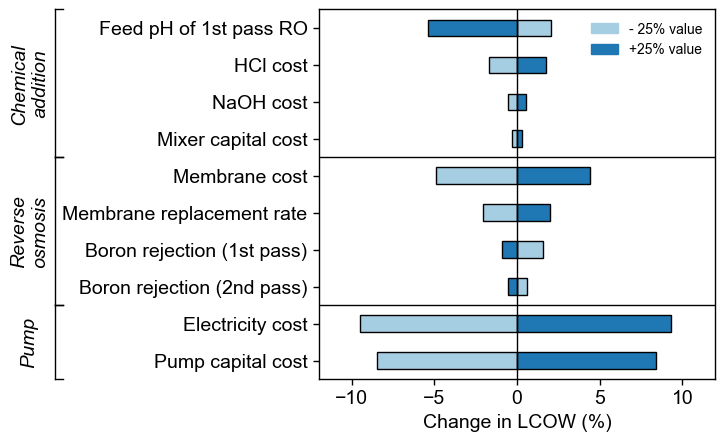

In [5]:
# ---------------------------------------------------------------------------
# Single axis for bars. Group labels/brackets drawn in figure coordinates
# so they live entirely in the left margin and never overlap ax content.
# ---------------------------------------------------------------------------
fig, ax_bar = plt.subplots()
fig.patch.set_facecolor('white')

# Reserve left margin space for group labels
fig.subplots_adjust(left=0.28)

# -----------------------------------------------------------------------
# Tornado bars
# -----------------------------------------------------------------------
y_pos = np.arange(n)

for i, row in enumerate(rows):
    ax_bar.barh(y_pos[i], row['lcow_low'],  left=BASELINE, height=BAR_HEIGHT,
                color=COLOR_LOW,  edgecolor='black', zorder=3)
    ax_bar.barh(y_pos[i], row['lcow_high'], left=BASELINE, height=BAR_HEIGHT,
                color=COLOR_HIGH, edgecolor='black', zorder=3)

# Vertical baseline
ax_bar.axvline(x=BASELINE, color='black', linewidth=1, zorder=5)

# Y-axis parameter labels
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels([r['label'] for r in rows], fontsize=14)
ax_bar.tick_params(axis='y', length=4, pad=4, width=1)
ax_bar.set_ylim(-0.5, n - 0.5)

# X-axis
xlim = 12
ax_bar.set_xlim(-xlim, xlim)
ax_bar.set_xlabel('Change in LCOW (%)', fontsize=14)
ax_bar.tick_params(axis='x', labelsize=14, width=1, length=4)
# Make x tick labels bold
# for label in ax_bar.get_xticklabels():
#     # label.set_fontweight('bold')

# Grid & spines — dark black border, bold
ax_bar.set_axisbelow(True)
ax_bar.set_facecolor('white')
for spine in ax_bar.spines.values():
    spine.set_linewidth(1)
    spine.set_color('black')

# -----------------------------------------------------------------------
# Compute group spans
# -----------------------------------------------------------------------
group_spans = {}
for i, row in enumerate(rows):
    g = row['group']
    if g not in group_spans:
        group_spans[g] = [i, i]
    else:
        group_spans[g][1] = max(group_spans[g][1], i)

grp_names_bottomup = list(dict.fromkeys(r['group'] for r in rows))

group_boundaries = []
group_midpoints  = []
for idx, gname in enumerate(grp_names_bottomup):
    y_bot, y_top = group_spans[gname]
    group_midpoints.append((gname, (y_bot + y_top) / 2.0))
    if idx < len(grp_names_bottomup) - 1:
        boundary_y = y_top + 0.5
        group_boundaries.append(boundary_y)
        ax_bar.axhline(y=boundary_y, color='black', linewidth=1, zorder=4)

# Legend
low_patch  = mpatches.Patch(color=COLOR_LOW,  label='- 25% value')
high_patch = mpatches.Patch(color=COLOR_HIGH, label='+25% value')
leg = ax_bar.legend(handles=[low_patch, high_patch], loc='upper right',
                    frameon=False, fontsize=10)
# for text in leg.get_texts():
#     text.set_fontweight('bold')

# -----------------------------------------------------------------------
# Group labels and brackets in figure coordinates.
# -----------------------------------------------------------------------
fig.canvas.draw()  # force layout so transforms are accurate

def data_y_to_fig(y_data):
    disp   = ax_bar.transData.transform((0, y_data))
    fig_pt = fig.transFigure.inverted().transform(disp)
    return fig_pt[1]

x_bracket = -0.132   # right edge of bracket — just left of ax left spine
x_label   = x_bracket+ -0.04   # centre of rotated label text
bracket_w  = 0.012  # length of horizontal end-ticks on the bracket

for gname, y_mid in group_midpoints:
    y_bot, y_top = group_spans[gname]

    fy_mid   = data_y_to_fig(y_mid)
    fy_lower = data_y_to_fig(y_bot - 0.5)
    fy_upper = data_y_to_fig(y_top + 0.5)

    # Rotated italic bold label
    fig.text(x_label, fy_mid, gname,
             ha='center', va='center',
             fontsize=14, style='italic',
             rotation=90,
             transform=fig.transFigure)

    # Vertical bracket line
    fig.add_artist(plt.Line2D(
        [x_bracket, x_bracket], [fy_lower, fy_upper],
        color='black', linewidth=1,
        transform=fig.transFigure, clip_on=False,
    ))

    # Horizontal end-ticks
    for fy_end in [fy_lower, fy_upper]:
        fig.add_artist(plt.Line2D(
            [x_bracket, x_bracket + bracket_w], [fy_end, fy_end],
            color='black', linewidth=1,
            transform=fig.transFigure, clip_on=False,
        ))

plt.savefig('boron_sensitivity_tornado.png', dpi=600, bbox_inches='tight')
plt.show()